In [51]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [52]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Convertir a DataFrame
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
boston = pd.DataFrame(data, columns=column_names)
boston['MEDV'] = target

print(boston.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [53]:
print("Informacion del dataset:")
print(boston.keys())
print()
print("Caracteristicas del dataset:")
print(boston.describe())
print(boston.shape)
print(df.isnull().sum().sum())  # 0 → no hay valores nulos


Informacion del dataset:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Caracteristicas del dataset:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO        

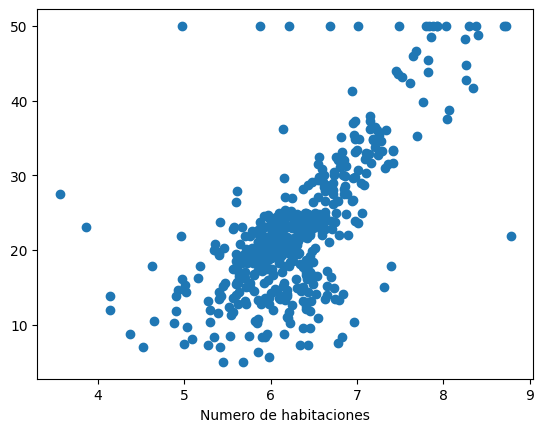

In [54]:
#definimos columna 5 del dataset, cantidad de habitaciones
x = boston[['RM']]
#columna a predecir, precio de la vivienda
y = boston['MEDV']

#graficamos los datos correspondientes
plt.scatter(x,y)
plt.xlabel('Numero de habitaciones')
plt.show()


In [ ]:
#####IMPLEMENTACION DE LA REGRESION LINEAL SIMPLE ####

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#separo los datos de train en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
lr = linear_model.LinearRegression()

#Entreno el modelo
lr.fit(x_train, y_train)

# extra-Predicciones sobre TRAIN
y_pred_train = lr.predict(x_train)

# extra-R² de TRAIN
#r2_train = r2_score(y_train, y_pred_train)

#Realizo una prediccion
y_pred = lr.predict(x_test)

r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)



print(f"Pendiente (coef):  {lr.coef_[0]:.4f}")
print(f"Intercepto:        {lr.intercept_:.4f}")
print(f"MSE:               {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²:                {r2_test:.4f}")
print(f"R²train:           {r2_train:.4f}")
print(f"Diferencia: {r2_train - r2_test:.4f}")


Pendiente (coef):  8.9040
Intercepto:        -33.2508
MSE:               35.5997
R²:                0.5187068040204477
R²train:           0.47300160203516695
Diferencia: -0.0457


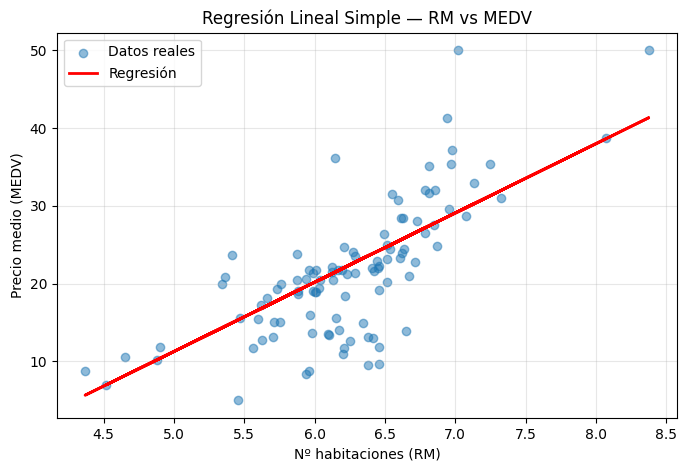

In [67]:
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, alpha=0.5, label='Datos reales')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regresión')
plt.xlabel('Nº habitaciones (RM)')
plt.ylabel('Precio medio (MEDV)')
plt.title('Regresión Lineal Simple — RM vs MEDV')
plt.legend()
plt.grid(alpha=0.3)
plt.show()